In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [7]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

Số ảnh train: 60000,  test: 10000


In [8]:

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

def train_model(model, train_loader, test_loader, num_epochs=5, lr=0.01):
    """Huấn luyện model và trả về lịch sử loss/acc."""
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_history, acc_history = [], []
    test_loss_history, test_acc_history = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total
        test_loss, test_acc = evaluate(model, test_loader)
        loss_history.append(train_loss); acc_history.append(train_acc)
        test_loss_history.append(test_loss); test_acc_history.append(test_acc)

        print(f'Epoch {epoch+1}/{num_epochs}  '
              f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
              f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

    return loss_history, acc_history, test_loss_history, test_acc_history

In [9]:
model_q1 = MNIST_CNN().to(device)
print(f'Tổng tham số: {sum(p.numel() for p in model_q1.parameters() if p.requires_grad):,}')

num_epochs = 10
loss_h, acc_h, test_loss_h, test_acc_h = train_model(
    model_q1, train_loader, test_loader, num_epochs=num_epochs, lr=0.01
)

Tổng tham số: 12,810
Epoch 1/10  train_loss=0.1822  train_acc=94.27%  test_loss=0.0635  test_acc=97.95%
Epoch 2/10  train_loss=0.0652  train_acc=98.07%  test_loss=0.0561  test_acc=98.18%
Epoch 3/10  train_loss=0.0495  train_acc=98.49%  test_loss=0.0414  test_acc=98.72%
Epoch 4/10  train_loss=0.0423  train_acc=98.70%  test_loss=0.0489  test_acc=98.50%
Epoch 5/10  train_loss=0.0370  train_acc=98.80%  test_loss=0.0422  test_acc=98.58%
Epoch 6/10  train_loss=0.0315  train_acc=99.03%  test_loss=0.0323  test_acc=99.05%
Epoch 7/10  train_loss=0.0282  train_acc=99.09%  test_loss=0.0351  test_acc=98.89%
Epoch 8/10  train_loss=0.0249  train_acc=99.18%  test_loss=0.0359  test_acc=98.88%
Epoch 9/10  train_loss=0.0221  train_acc=99.31%  test_loss=0.0380  test_acc=98.80%
Epoch 10/10  train_loss=0.0202  train_acc=99.32%  test_loss=0.0346  test_acc=98.91%


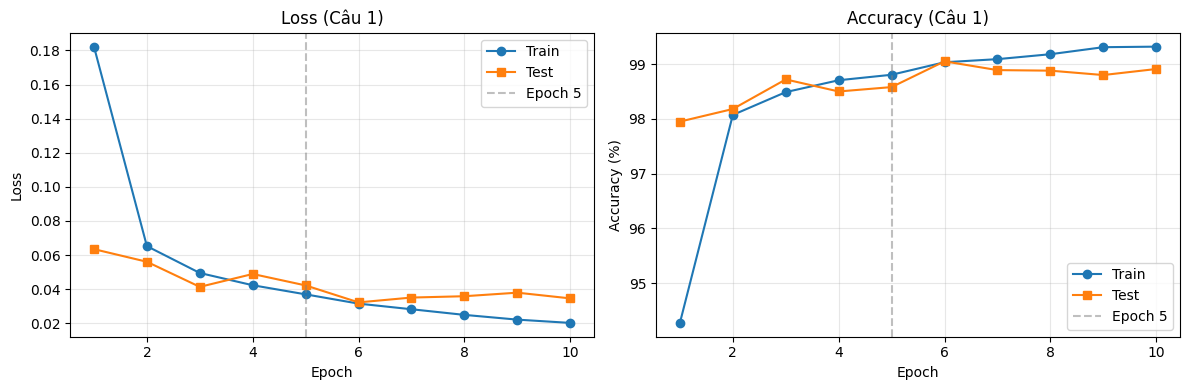

Test accuracy @ epoch  5: 98.58%
Test accuracy @ epoch 10: 98.91%
Train–Test gap @ epoch  5: 0.22%
Train–Test gap @ epoch 10: 0.41%


In [10]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_h,      'o-', label='Train')
axes[0].plot(epochs, test_loss_h, 's-', label='Test')
axes[0].axvline(5, color='gray', linestyle='--', alpha=0.5, label='Epoch 5')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Loss (Câu 1)')

axes[1].plot(epochs, [a*100 for a in acc_h],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_h], 's-', label='Test')
axes[1].axvline(5, color='gray', linestyle='--', alpha=0.5, label='Epoch 5')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title('Accuracy (Câu 1)')
plt.tight_layout(); plt.show()

gap_epoch5  = (acc_h[4]  - test_acc_h[4])  * 100
gap_epoch10 = (acc_h[9] - test_acc_h[9]) * 100
print(f'Test accuracy @ epoch  5: {test_acc_h[4]*100:.2f}%')
print(f'Test accuracy @ epoch 10: {test_acc_h[9]*100:.2f}%')
print(f'Train–Test gap @ epoch  5: {gap_epoch5:.2f}%')
print(f'Train–Test gap @ epoch 10: {gap_epoch10:.2f}%')

In [11]:
class MNIST_CNN_3Conv(nn.Module):
    """
    Kiến trúc mở rộng với 3 tầng Conv:
      Input  (1, 28, 28)
      Conv1 (1→16, k=3, p=0)  → (16, 26, 26) → Pool → (16, 13, 13)
      Conv2 (16→32, k=3, p=0) → (32, 11, 11) → Pool → (32,  5,  5)
      Conv3 (32→64, k=3, p=1) → (64,  5,  5) → Pool → (64,  2,  2)  [floor(5/2)=2]
      Flatten → 64*2*2 = 256
      FC (256 → 10)
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,  16, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = self.fc1(x)
        return x

model_q2 = MNIST_CNN_3Conv().to(device)
print(model_q2)
print(f'Tổng tham số: {sum(p.numel() for p in model_q2.parameters() if p.requires_grad):,}')

MNIST_CNN_3Conv(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866


In [12]:
loss_h2, acc_h2, test_loss_h2, test_acc_h2 = train_model(
    model_q2, train_loader, test_loader, num_epochs=5, lr=0.01
)

_, test_acc_base = evaluate(model_q1, test_loader)
print(f'\nTest accuracy — 2 conv (5 epoch): {test_acc_h[4]*100:.2f}%')
print(f'Test accuracy — 3 conv (5 epoch): {test_acc_h2[-1]*100:.2f}%')

Epoch 1/5  train_loss=0.2141  train_acc=93.21%  test_loss=0.0614  test_acc=98.15%
Epoch 2/5  train_loss=0.0579  train_acc=98.26%  test_loss=0.0407  test_acc=98.63%
Epoch 3/5  train_loss=0.0410  train_acc=98.67%  test_loss=0.0338  test_acc=98.82%
Epoch 4/5  train_loss=0.0326  train_acc=98.98%  test_loss=0.0356  test_acc=98.83%
Epoch 5/5  train_loss=0.0267  train_acc=99.11%  test_loss=0.0311  test_acc=98.97%

Test accuracy — 2 conv (5 epoch): 98.58%
Test accuracy — 3 conv (5 epoch): 98.97%


In [13]:
learning_rates = [0.001, 0.01, 0.1]
colors = ['steelblue', 'darkorange', 'firebrick']
results_lr = {}

for lr in learning_rates:
    print(f'\n--- Training với lr = {lr} ---')
    m = MNIST_CNN().to(device)
    torch.manual_seed(42)
    lh, ah, tlh, tah = train_model(m, train_loader, test_loader, num_epochs=5, lr=lr)
    results_lr[lr] = {'train_loss': lh, 'test_loss': tlh,
                      'train_acc': ah, 'test_acc': tah}


--- Training với lr = 0.001 ---
Epoch 1/5  train_loss=0.4265  train_acc=87.91%  test_loss=0.1625  test_acc=95.12%
Epoch 2/5  train_loss=0.1480  train_acc=95.70%  test_loss=0.1093  test_acc=96.68%
Epoch 3/5  train_loss=0.1095  train_acc=96.81%  test_loss=0.0951  test_acc=96.94%
Epoch 4/5  train_loss=0.0902  train_acc=97.31%  test_loss=0.0783  test_acc=97.60%
Epoch 5/5  train_loss=0.0792  train_acc=97.62%  test_loss=0.0641  test_acc=97.94%

--- Training với lr = 0.01 ---
Epoch 1/5  train_loss=0.1852  train_acc=94.23%  test_loss=0.0691  test_acc=97.84%
Epoch 2/5  train_loss=0.0612  train_acc=98.13%  test_loss=0.0539  test_acc=98.34%
Epoch 3/5  train_loss=0.0484  train_acc=98.51%  test_loss=0.0455  test_acc=98.53%
Epoch 4/5  train_loss=0.0402  train_acc=98.72%  test_loss=0.0416  test_acc=98.56%
Epoch 5/5  train_loss=0.0337  train_acc=99.01%  test_loss=0.0354  test_acc=98.86%

--- Training với lr = 0.1 ---
Epoch 1/5  train_loss=0.2026  train_acc=93.95%  test_loss=0.1168  test_acc=96.33%
Ep

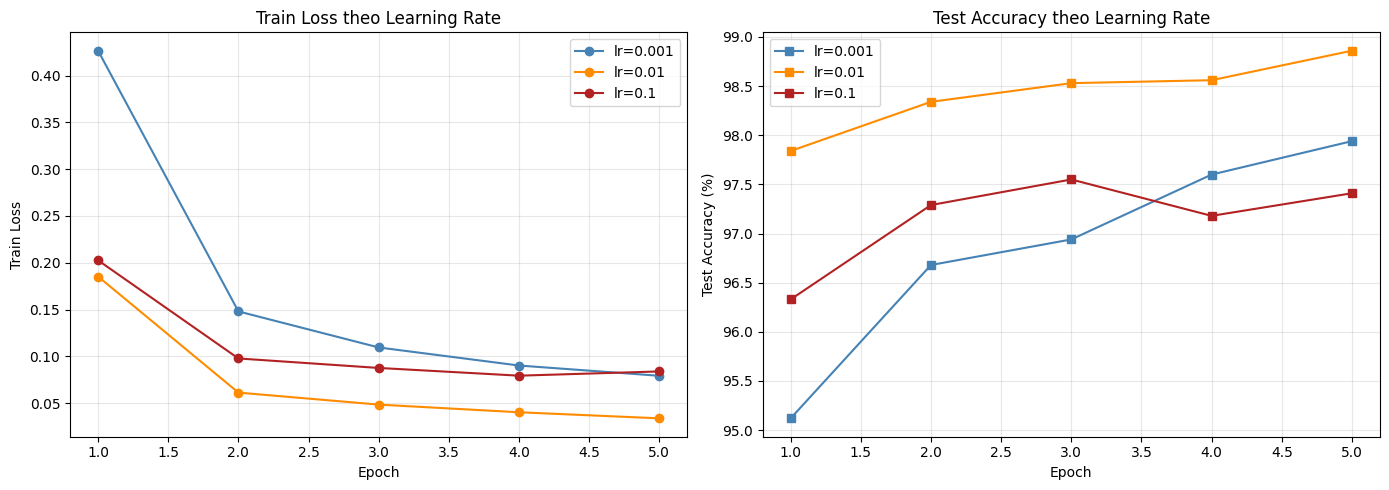

lr=0.001: final test_acc=97.94%
lr=0.01: final test_acc=98.86%
lr=0.1: final test_acc=97.41%


In [14]:
epochs = range(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (lr, res), c in zip(results_lr.items(), colors):
    axes[0].plot(epochs, res['train_loss'], 'o-', color=c, label=f'lr={lr}')
    axes[1].plot(epochs, [a*100 for a in res['test_acc']], 's-', color=c, label=f'lr={lr}')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Train Loss theo Learning Rate')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title('Test Accuracy theo Learning Rate')
plt.tight_layout(); plt.show()

for lr, res in results_lr.items():
    print(f'lr={lr}: final test_acc={res["test_acc"][-1]*100:.2f}%')

In [15]:

model_q1.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)


with torch.no_grad():
    h1 = torch.relu(model_q1.conv1(img))
    h1_pooled = model_q1.pool(h1)
    h2 = torch.relu(model_q1.conv2(h1_pooled))

print(f'Shape feature map conv1: {h1.shape}')
print(f'Shape feature map conv2: {h2.shape}')

Shape feature map conv1: torch.Size([1, 16, 26, 26])
Shape feature map conv2: torch.Size([1, 32, 11, 11])


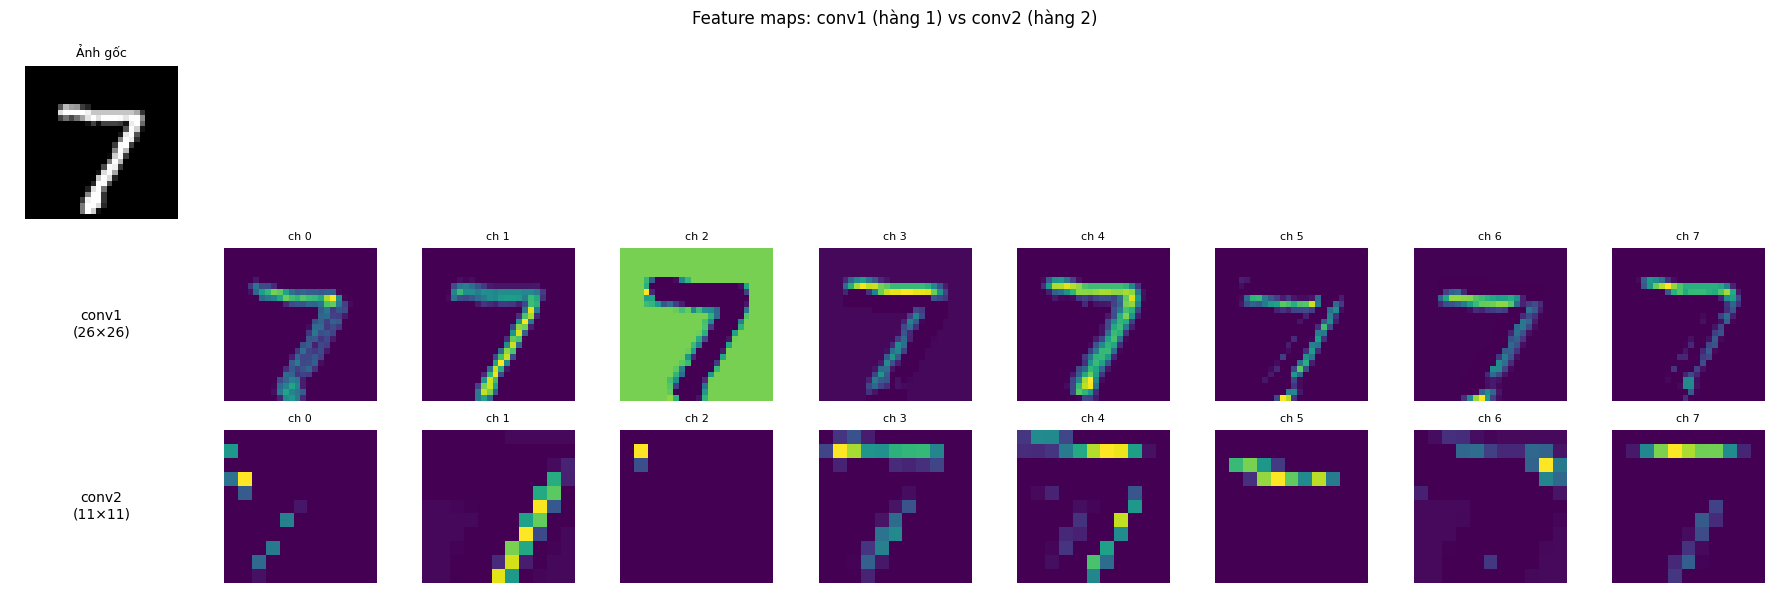

In [16]:

n_show = 8
fig, axes = plt.subplots(3, n_show + 1, figsize=(18, 6))


orig = img.cpu().squeeze() * 0.3081 + 0.1307
axes[0, 0].imshow(orig, cmap='gray')
axes[0, 0].set_title('Ảnh gốc', fontsize=9)
axes[0, 0].axis('off')
for j in range(1, n_show + 1):
    axes[0, j].axis('off')


axes[1, 0].text(0.5, 0.5, 'conv1\n(26×26)', ha='center', va='center',
                fontsize=10, transform=axes[1, 0].transAxes)
axes[1, 0].axis('off')
for j in range(n_show):
    axes[1, j+1].imshow(h1[0, j].cpu(), cmap='viridis')
    axes[1, j+1].set_title(f'ch {j}', fontsize=8)
    axes[1, j+1].axis('off')

axes[2, 0].text(0.5, 0.5, 'conv2\n(11×11)', ha='center', va='center',
                fontsize=10, transform=axes[2, 0].transAxes)
axes[2, 0].axis('off')
for j in range(n_show):
    axes[2, j+1].imshow(h2[0, j].cpu(), cmap='viridis')
    axes[2, j+1].set_title(f'ch {j}', fontsize=8)
    axes[2, j+1].axis('off')

plt.suptitle('Feature maps: conv1 (hàng 1) vs conv2 (hàng 2)', fontsize=12)
plt.tight_layout(); plt.show()

In [17]:

transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True,
                                                download=True, transform=transform_aug)
train_loader_aug  = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)


print('Dataset với augmentation đã tạo.')

Dataset với augmentation đã tạo.


In [18]:
class MNIST_CNN_Dropout(nn.Module):
    """
    Model gốc + Dropout(p=0.25) thêm sau pool cuối cùng, trước fc1.
    Dropout ngẫu nhiên tắt 25% neuron trong mỗi bước train
    → buộc mạng không phụ thuộc quá vào bất kỳ neuron nào → giảm overfitting.
    """
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 16, kernel_size=3, padding=0)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, padding=0)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1     = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model_q5 = MNIST_CNN_Dropout().to(device)
print(model_q5)
print(f'Tổng tham số: {sum(p.numel() for p in model_q5.parameters() if p.requires_grad):,}')

MNIST_CNN_Dropout(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [19]:
print('=== Model với Dropout + Augmentation (10 epoch) ===')
loss_h5, acc_h5, test_loss_h5, test_acc_h5 = train_model(
    model_q5, train_loader_aug, test_loader, num_epochs=10, lr=0.01
)

=== Model với Dropout + Augmentation (10 epoch) ===
Epoch 1/10  train_loss=0.4266  train_acc=86.29%  test_loss=0.0544  test_acc=98.43%
Epoch 2/10  train_loss=0.1758  train_acc=94.48%  test_loss=0.0490  test_acc=98.37%
Epoch 3/10  train_loss=0.1430  train_acc=95.56%  test_loss=0.0406  test_acc=98.72%
Epoch 4/10  train_loss=0.1225  train_acc=96.22%  test_loss=0.0310  test_acc=99.05%
Epoch 5/10  train_loss=0.1125  train_acc=96.57%  test_loss=0.0343  test_acc=98.79%
Epoch 6/10  train_loss=0.1060  train_acc=96.66%  test_loss=0.0305  test_acc=99.02%
Epoch 7/10  train_loss=0.1066  train_acc=96.74%  test_loss=0.0272  test_acc=99.21%
Epoch 8/10  train_loss=0.1002  train_acc=96.84%  test_loss=0.0282  test_acc=99.15%
Epoch 9/10  train_loss=0.0978  train_acc=96.91%  test_loss=0.0366  test_acc=98.77%
Epoch 10/10  train_loss=0.0919  train_acc=97.15%  test_loss=0.0263  test_acc=99.08%


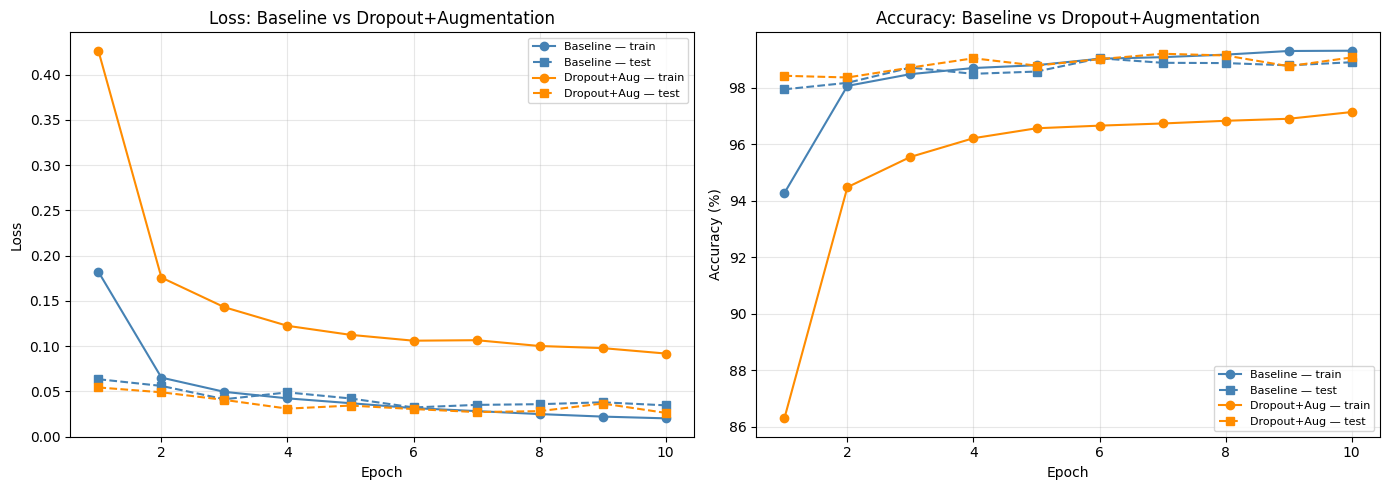

Baseline    — test acc: 98.91%,  train–test gap: 0.41%
Dropout+Aug — test acc: 99.08%, train–test gap: -1.93%


In [20]:
epochs_10 = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_10, loss_h,  'o-', color='steelblue', label='Baseline — train')
axes[0].plot(epochs_10, test_loss_h, 's--', color='steelblue', label='Baseline — test')
axes[0].plot(epochs_10, loss_h5, 'o-', color='darkorange', label='Dropout+Aug — train')
axes[0].plot(epochs_10, test_loss_h5, 's--', color='darkorange', label='Dropout+Aug — test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss: Baseline vs Dropout+Augmentation')


axes[1].plot(epochs_10, [a*100 for a in acc_h],  'o-', color='steelblue', label='Baseline — train')
axes[1].plot(epochs_10, [a*100 for a in test_acc_h], 's--', color='steelblue', label='Baseline — test')
axes[1].plot(epochs_10, [a*100 for a in acc_h5], 'o-', color='darkorange', label='Dropout+Aug — train')
axes[1].plot(epochs_10, [a*100 for a in test_acc_h5], 's--', color='darkorange', label='Dropout+Aug — test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy: Baseline vs Dropout+Augmentation')
plt.tight_layout(); plt.show()

gap_base = (acc_h[-1] - test_acc_h[-1]) * 100
gap_drop = (acc_h5[-1] - test_acc_h5[-1]) * 100
print(f'Baseline    — test acc: {test_acc_h[-1]*100:.2f}%,  train–test gap: {gap_base:.2f}%')
print(f'Dropout+Aug — test acc: {test_acc_h5[-1]*100:.2f}%, train–test gap: {gap_drop:.2f}%')